# Projeto Final — RideSmart
## Modelagem e Análise de Rotas Urbanas com Grafos


### Resumo do problema

Dado um ponto de origem `A`, um destino `B` e uma distância máxima de caminhada `X`, o objetivo é
escolher um **ponto de embarque** `P` (a no máximo `X` metros de caminhada de `A`) que minimize o
custo total da viagem, composta por dois trechos:

```text
A → P   (a pé)
P → B   (de carro)
```

O notebook modela a malha viária real como grafo, implementa e compara quatro algoritmos de caminho
mínimo, introduz **trânsito sintético** e analisa o *trade-off* entre caminhar um pouco e chegar
mais rápido.

## 1. Modelagem do problema como grafo

**Grafo dirigido com multiarestas** $G = (V, E)$ obtido do OpenStreetMap via OSMnx:

- **Nós ($V$):** cruzamentos e extremidades de vias. Cada nó possui coordenadas geográficas
  (`y` = latitude, `x` = longitude).
- **Arestas ($E$):** segmentos de rua entre dois cruzamentos. O grafo é um `MultiDiGraph`:
  é **dirigido** (modela ruas de mão única) e admite **arestas paralelas** (duas ruas distintas
  ligando o mesmo par de cruzamentos).

**Funções de custo (pesos das arestas):**

| Peso | Significado | Usado para |
|---|---|---|
| `length` | comprimento do segmento em metros | menor **distância** e caminhada `A→P` |
| `travel_time` | tempo de percurso de carro em segundos (sem trânsito) | rota mais **rápida** |
| `travel_time_traffic` | `travel_time` ajustado por um fator de congestionamento | rota mais rápida **com trânsito** |

O tempo de caminhada é derivado do comprimento por uma velocidade fixa de pedestre
($v_{pe} \approx 1{,}4$ m/s $\approx 5$ km/h):
$$t_{pe}(A \to P) = \frac{\text{distância}_{length}(A \to P)}{v_{pe}}.$$

O **custo total** de uma escolha de embarque `P` é:
$$\text{custo}(P) = t_{pe}(A \to P) + \text{custo}_{carro}(P \to B),$$
sujeito à restrição $\text{distância}_{length}(A \to P) \le X$.

## 2. Configuração do ambiente

Em ambientes como o Google Colab, descomente a instalação abaixo. O OSMnx requer acesso à internet
para baixar os dados do OpenStreetMap.

In [1]:
!pip install osmnx networkx pandas matplotlib scikit-learn numpy matplotlib osmnx

import time, copy, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox

ox.settings.use_cache = True          # cacheia o download (re-execuções ficam instantâneas)
ox.settings.log_console = False
print("OSMnx", ox.__version__, "| NetworkX", nx.__version__)

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 480.3 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.1 MB 480.3 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.1 MB 480.3 kB/s eta 0:00:04
   --------------- ------------------------ 0.8/2.1 MB 465.9 kB/s eta 0:00:03
   --------------- ------------------------ 0.8/2.1 MB 465.9 kB/s eta 0:00:03
   --------------- ------------------------ 0.8/2.1 MB 465.9 kB/s eta 0:00:03
   -------------------- ------------------- 1.0/2.1 MB 443.2 kB/s eta 0:00:03
   -------------------- ----------------

## 3. Download da malha viária real

Baixamos a rede **dirigível** (`network_type="drive"`) num raio em torno de um ponto central da
cidade. Em seguida o OSMnx imputa velocidades por tipo de via (`add_edge_speeds`) e calcula o tempo
de percurso de cada aresta (`add_edge_travel_times`).

In [5]:
# Centro da área de estudo (exemplo: bairro de Petrópolis / Tirol, Natal-RN).
# Troque pelas coordenadas da sua cidade/bairro.
CENTRO = (-5.8000, -35.2050)   # (lat, lon)
RAIO_M = 2500                  # raio da malha em metros

G = ox.graph_from_point(CENTRO, dist=RAIO_M, network_type="drive")

# velocidades (km/h) e tempos de percurso (s) por aresta
try:
    G = ox.routing.add_edge_speeds(G)
    G = ox.routing.add_edge_travel_times(G)
except AttributeError:                 # compatibilidade com versões antigas
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)

print(f"[drive] Nós: {G.number_of_nodes()}  |  Arestas: {G.number_of_edges()}")
u, v, k, d = list(G.edges(keys=True, data=True))[0]
print(f"  Aresta exemplo: {d.get('name')} | length={d.get('length'):.1f}m | travel_time={d.get('travel_time'):.1f}s")

# Grafo separado para caminhada (inclui calçadas e vias de pedestre)
G_walk = ox.graph_from_point(CENTRO, dist=RAIO_M, network_type="walk")
print(f"[walk]  Nós: {G_walk.number_of_nodes()}  |  Arestas: {G_walk.number_of_edges()}")

[drive] Nós: 3104  |  Arestas: 6762
  Aresta exemplo: Avenida Governador Sílvio Pedroza | length=28.2m | travel_time=1.9s
[walk]  Nós: 4929  |  Arestas: 14456


## 4. Definição de origem `A`, destino `B`, distância máxima `X`

Escolhemos coordenadas reais de `A` e `B` e mapeamos cada uma para o nó mais próximo da malha
(`nearest_nodes`). `X` é a distância máxima que o usuário aceita caminhar; `V_PE` é a velocidade de
caminhada.

In [6]:
# Coordenadas de origem e destino (lat, lon) — ajuste conforme sua cidade
A_latlon = (-5.7935, -35.2010)
B_latlon = (-5.8120, -35.1980)

X      = 600.0    # distância máxima de caminhada (metros)
V_PE   = 1.4      # velocidade de caminhada (m/s) ~ 5 km/h

A = ox.distance.nearest_nodes(G, A_latlon[1], A_latlon[0])
B = ox.distance.nearest_nodes(G, B_latlon[1], B_latlon[0])
A_walk = ox.distance.nearest_nodes(G_walk, A_latlon[1], A_latlon[0])
print(f"Nó de origem  A = {A}  (walk: {A_walk})")
print(f"Nó de destino B = {B}")

# velocidade máxima do grafo (m/s) — usada na heurística do A* para tempo
VMAX_MS = max(d.get('speed_kph', 1) for _,_,d in G.edges(data=True)) / 3.6
print(f"Velocidade máxima do grafo: {VMAX_MS*3.6:.0f} km/h")

Nó de origem  A = 8626298111  (walk: 7616423477)
Nó de destino B = 503422480
Velocidade máxima do grafo: 70 km/h


## 5. Implementação dos algoritmos

Nesta seção implementaremos quatro algoritmos de caminho mínimo:

1. **Dijkstra simples** — implementação clássica $O(V^2)$
2. **Dijkstra com fila de prioridade (heap)** — implementação manual com `heapq` do Python
3. **A* com heurística geográfica** — A* usando distância geográfica como heurística
4. **Bellman-Ford** — algoritmo robusto que lida com arestas negativas

Cada algoritmo será:
- Implementado e testado com pelo menos 2 pares de nós
- Medido em tempo de execução e nós expandidos
- Coletado para comparação posterior

### 5.1 Bellman-Ford — implementação manual

O Bellman-Ford calcula caminhos mínimos a partir de uma origem em grafos com arestas de peso
arbitrário (inclusive negativas). Funciona com **V-1 rodadas de relaxação** sobre todas as arestas;
uma rodada extra detecta **ciclos de peso negativo**.

| Aspecto | Detalhe |
|---|---|
| Complexidade | $O(V \cdot E)$ |
| Grafos negativos | Suporta (diferente do Dijkstra) |
| Ciclos negativos | Detecta na iteração $V$ |
| Uso aqui | Base para comparação de desempenho |

In [15]:
import time
import math


def _vizinhos_ponderados(G, no, weight='travel_time'):
    if G.is_multigraph():
        for vizinho, arestas in G[no].items():
            menor_peso = float('inf')
            for data in arestas.values():
                menor_peso = min(menor_peso, data.get(weight, float('inf')))
            yield vizinho, menor_peso
    else:
        for vizinho, data in G[no].items():
            yield vizinho, data.get(weight, float('inf'))


def _distancia_geografica_m(G, origem, destino):
    lat1 = math.radians(G.nodes[origem]['y'])
    lon1 = math.radians(G.nodes[origem]['x'])
    lat2 = math.radians(G.nodes[destino]['y'])
    lon2 = math.radians(G.nodes[destino]['x'])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2.0 * 6371000.0 * math.asin(math.sqrt(a))


def _reconstruir_caminho(prev, destino):
    caminho = []
    no = destino
    while no is not None:
        caminho.append(no)
        no = prev[no]
    caminho.reverse()
    return caminho


def dijkstra_simples(G, origem, destino, weight='travel_time'):
    """
    Dijkstra clássico com busca linear do próximo nó a expandir.
    Retorna dict com: 'distancia','caminho','expandidos','ciclo_negativo'(False),'tempo'.
    """
    t0 = time.perf_counter()
    dist = {n: float('inf') for n in G.nodes()}
    prev = {n: None for n in G.nodes()}
    nao_visitados = set(G.nodes())
    dist[origem] = 0.0
    expandidos = 0

    while nao_visitados:
        atual = min(nao_visitados, key=lambda n: dist[n])
        if dist[atual] == float('inf'):
            break

        nao_visitados.remove(atual)
        if atual == destino:
            break

        for vizinho, peso in _vizinhos_ponderados(G, atual, weight):
            expandidos += 1
            if vizinho in nao_visitados:
                novo_custo = dist[atual] + peso
                if novo_custo < dist[vizinho]:
                    dist[vizinho] = novo_custo
                    prev[vizinho] = atual

    caminho = []
    if dist[destino] < float('inf'):
        caminho = _reconstruir_caminho(prev, destino)

    return {
        'distancia': dist[destino],
        'caminho': caminho,
        'expandidos': expandidos,
        'ciclo_negativo': False,
        'tempo': time.perf_counter() - t0,
    }


def bellman_ford(G, origem, destino, weight='travel_time'):
    """
    Bellman-Ford manual.

    Retorna dict com:
      - 'distancia': custo total do caminho (ou inf se inalcançável)
      - 'caminho': lista de nós do caminho
      - 'expandidos': nº de arestas relaxadas (= arestas totais, O(V*E))
      - 'ciclo_negativo': True se detectado ciclo de peso negativo
      - 'tempo': tempo de execução em segundos
    """
    t0 = time.perf_counter()

    # inicialização
    dist = {n: float('inf') for n in G.nodes()}
    prev = {n: None for n in G.nodes()}
    dist[origem] = 0.0

    # todas as arestas (u, v, peso)
    edges = [(u, v, d.get(weight, float('inf'))) for u, v, d in G.edges(data=True)]
    V = G.number_of_nodes()
    expandidos = 0

    # V-1 rodadas de relaxação
    for _ in range(V - 1):
        atualizou = False
        for u, v, w in edges:
            expandidos += 1
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u
                atualizou = True
        if not atualizou:          # convergiu antes de V-1 rodadas
            break

    # iteração extra: detecção de ciclo negativo
    ciclo_negativo = False
    for u, v, w in edges:
        expandidos += 1
        if dist[u] + w < dist[v]:
            ciclo_negativo = True
            break

    # reconstrução do caminho
    caminho = []
    if dist[destino] < float('inf'):
        no = destino
        while no is not None:
            caminho.append(no)
            no = prev[no]
        caminho.reverse()

    t_total = time.perf_counter() - t0

    return {
        'distancia': dist[destino],
        'caminho': caminho,
        'expandidos': expandidos,
        'ciclo_negativo': ciclo_negativo,
        'tempo': t_total,
    }

In [14]:
# Teste Dijkstra simples com 2 pares de nós + persistência JSON
print("="*60)
print("DIJKSTRA SIMPLES — TESTES")
print("="*60)

nos_lista = list(G.nodes())
n2_orig = nos_lista[len(nos_lista) // 3]
n2_dest = nos_lista[2 * len(nos_lista) // 3]

pares = [
    ("Par 1", A, B),
    ("Par 2", n2_orig, n2_dest),
]

resultados_dijkstra = {}

for nome_par, origem, destino in pares:
    resultado = dijkstra_simples(G, origem, destino, weight='travel_time')
    resultados_dijkstra[nome_par] = resultado

    print(f"\n{nome_par}: {origem} → {destino}")
    print(f"  Distância: {resultado['distancia']:.1f}s")
    print(f"  Nós no caminho: {len(resultado['caminho'])}")
    print(f"  Expandidos: {resultado['expandidos']}")
    print(f"  Tempo: {resultado['tempo']*1000:.2f}ms")

# Persistir apenas os resultados do Dijkstra simples
import json
from pathlib import Path
Path('results').mkdir(exist_ok=True)

out = {
    'dijkstra_simples': resultados_dijkstra,
    'A': A,
    'B': B,
}

with open('results/dijkstra_simples_resultados.json', 'w', encoding='utf-8') as f:
    json.dump(out, f, indent=2, ensure_ascii=False)

print('\nResultado salvo em results/dijkstra_simples_resultados.json')

BELLMAN-FORD — Testes

Par 1: 8626298111 → 503422480
  Distância: 237.8s
  Nós no caminho: 38
  Arestas relaxadas: 297528
  Ciclo negativo: False
  Tempo: 29.42ms

Par 2: 526593101 → 5264901355
  Distância: 171.8s
  Nós no caminho: 22
  Arestas relaxadas: 297528
  Ciclo negativo: False
  Tempo: 28.23ms

Resultado armazenado para comparação.


## 6. Trânsito sintético

Modelamos o trânsito aplicando fatores de congestionamento baseados no tipo de via:

| Categoria de via | Fator de congestionamento |
|---|---|
| Arterial (motorway, trunk, primary) | 2.0 |
| Coletora (secondary, tertiary) | 1.5 |
| Residencial (residential, living_street) | 1.1 |

O trânsito sintético cria uma nova aresta `travel_time_traffic` = `travel_time` × fator,
permitindo comparar rotas com e sem congestionamento.

COMPARAÇÃO DE ARESTAS (Trânsito Sintético)
Via: Avenida Governador Sílvio Pedroza (primary)
  Tempo base (Sem Trânsito): 1.85s
  Tempo no Pico (18:00):      5.23s
  Tempo Fora de Pico (23:00): 2.89s

COMPARAÇÃO DE ROTAS (Com vs Sem Trânsito)
Rota mais rápida SEM trânsito (tempo base):
  Tempo total: 237.83s
  Número de nós no caminho: 38

Rota mais rápida COM trânsito (Pico 18h):
  Tempo total: 563.70s
  Número de nós no caminho: 40

Os caminhos escolhidos são diferentes? SIM


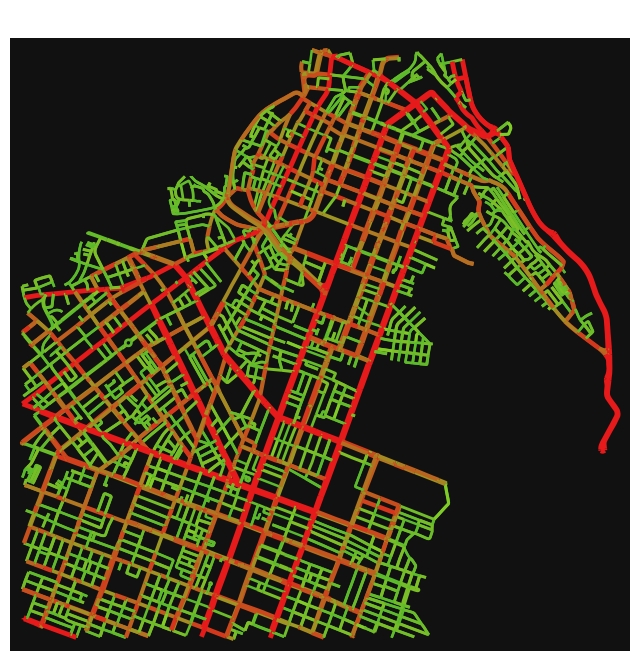

In [16]:
categorias_ruas = {
    'motorway': 'arterial', 
    'motorway_link': 'arterial',
    'trunk': 'arterial', 
    'trunk_link': 'arterial',
    'primary': 'arterial',
    'primary_link': 'arterial',
    'secondary': 'coletora', 
    'secondary_link': 'coletora',
    'tertiary': 'coletora', 
    'tertiary_link': 'coletora',
    'residential': 'residencial', 
    'living_street': 'residencial',
    'unclassified': 'residencial',
    'service': 'residencial',
}

fator_trafego = {
    'arterial': 2.0, 
    'coletora': 1.5, 
    'residencial': 1.1,
}

def obter_multiplicador_pico(hora):
    """
    Retorna um multiplicador de tráfego com base na hora do dia (0-23h).
    Pico da manhã: 07h-09h (máximo às 08h, multiplicador +30%)
    Pico da tarde: 17h-19h (máximo às 18h, multiplicador +45%)
    Madrugada: 22h-06h (multiplicador menor, 0.8x do tráfego padrão)
    Outros horários: 1.0x (tráfego padrão)
    """
    if 7.0 <= hora <= 9.0:
        dist = abs(hora - 8.0)
        return 1.0 + 0.30 * (1.0 - dist)
    elif 17.0 <= hora <= 19.0:
        dist = abs(hora - 18.0)
        return 1.0 + 0.45 * (1.0 - dist)
    elif 22.0 <= hora or hora <= 6.0:
        return 0.8
    else:
        return 1.0

def aplicar_transito_sintetico(grafo, hora=18.0, in_place=False, semente=42):
    """
    Aplica trânsito sintético no grafo baseado no tipo de via, no horário de pico e
    com uma componente estocástica (aleatória) para realismo.
    
    Retorna uma cópia do grafo com a propriedade 'travel_time_traffic' adicionada às arestas.
    """
    if not in_place:
        grafo = grafo.copy()
        
    if semente is not None:
        np.random.seed(semente)
        
    fator_pico = obter_multiplicador_pico(hora)
    
    for u, v, k, data in grafo.edges(keys=True, data=True):
        # Determina a categoria da via
        highway = data.get('highway', 'residencial')
        if isinstance(highway, list):
            highway = highway[0]
            
        categoria = categorias_ruas.get(highway, 'residencial')
        
        # Obtém o fator base da categoria e aplica o multiplicador de pico
        fator_base = fator_trafego.get(categoria, 1.0)
        
        # Adiciona variação estocástica (+/- 10%) para simular trânsito real e imprevisível
        variacao_estocastica = np.random.uniform(0.9, 1.1)
        
        fator_final = fator_base * fator_pico * variacao_estocastica
        # O trânsito não pode diminuir o tempo padrão abaixo do tempo livre de tráfego
        fator_final = max(1.0, fator_final)
        
        # Obtém o tempo de percurso base (travel_time)
        travel_time = data.get('travel_time', 0.0)
        
        # Fallback caso travel_time não esteja calculado
        if travel_time == 0.0 and 'length' in data:
            speed_kph = data.get('speed_kph', 30)
            if isinstance(speed_kph, list):
                speed_kph = speed_kph[0]
            speed_ms = speed_kph / 3.6
            travel_time = data['length'] / speed_ms if speed_ms > 0 else 1.0
            
        data['travel_time_traffic'] = travel_time * fator_final
        
    return grafo

def visualizar_transito(grafo, titulo="Visualização do Trânsito Sintético"):
    """
    Visualiza espacialmente o nível de congestionamento das vias do grafo.
    Cores: Verde (Fluido) -> Amarelo -> Vermelho (Congestionado).
    """
    cores = []
    larguras = []
    
    for u, v, k, data in grafo.edges(keys=True, data=True):
        t_base = data.get('travel_time', 1.0)
        t_trafego = data.get('travel_time_traffic', t_base)
        if t_base <= 0:
            t_base = 1.0
            
        # Fator de congestionamento real
        razao = t_trafego / t_base
        
        # Normaliza a razão de congestionamento de 1.0 (verde) a 2.5+ (vermelho)
        val = min(1.0, max(0.0, (razao - 1.0) / 1.5))
        
        # Gradiente suave de verde para vermelho:
        r = 0.1 + 0.8 * val
        g = 0.7 + 0.1 * val if val < 0.5 else 0.8 - 0.7 * (val - 0.5) * 2
        b = 0.2 - 0.1 * val
        cores.append((r, g, b))
        
        # Largura da linha maior para vias mais congestionadas
        largura = 1.0 + 2.5 * val
        larguras.append(largura)
    
    fig, ax = ox.plot_graph(
        grafo,
        node_size=0,
        edge_color=cores,
        edge_linewidth=larguras,
        bgcolor='#111111',
        show=False,
        close=False
    )
    ax.set_title(titulo, color='white', fontsize=14, pad=10)
    plt.show()

# --- TESTANDO ---

# 1. Gerar grafo com trânsito de pico (18:00) - Copiando o grafo para evitar mutar G
G_pico = aplicar_transito_sintetico(G, hora=18.0, in_place=False)

# 2. Gerar grafo fora de pico (23:00)
G_fora_pico = aplicar_transito_sintetico(G, hora=23.0, in_place=False)

# Exemplo de comparação de aresta
u, v, k, d_orig = list(G.edges(keys=True, data=True))[0]
_, _, _, d_pico = list(G_pico.edges(keys=True, data=True))[0]
_, _, _, d_fora = list(G_fora_pico.edges(keys=True, data=True))[0]

print("="*60)
print("COMPARAÇÃO DE ARESTAS (Trânsito Sintético)")
print("="*60)
print(f"Via: {d_orig.get('name', 'Sem nome')} ({d_orig.get('highway')})")
print(f"  Tempo base (Sem Trânsito): {d_orig.get('travel_time', 0.0):.2f}s")
print(f"  Tempo no Pico (18:00):      {d_pico.get('travel_time_traffic', 0.0):.2f}s")
print(f"  Tempo Fora de Pico (23:00): {d_fora.get('travel_time_traffic', 0.0):.2f}s")

# 3. Teste de comparação de rotas (Caminho mais rápido com e sem trânsito)
print("\n" + "="*60)
print("COMPARAÇÃO DE ROTAS (Com vs Sem Trânsito)")
print("="*60)
try:
    # Usando o algoritmo de Bellman-Ford já implementado na Seção 5.1
    caminho_sem = bellman_ford(G, A, B, weight='travel_time')
    caminho_com = bellman_ford(G_pico, A, B, weight='travel_time_traffic')
    
    print(f"Rota mais rápida SEM trânsito (tempo base):")
    print(f"  Tempo total: {caminho_sem['distancia']:.2f}s")
    print(f"  Número de nós no caminho: {len(caminho_sem['caminho'])}")
    
    print(f"\nRota mais rápida COM trânsito (Pico 18h):")
    print(f"  Tempo total: {caminho_com['distancia']:.2f}s")
    print(f"  Número de nós no caminho: {len(caminho_com['caminho'])}")
    
    diferentes = caminho_sem['caminho'] != caminho_com['caminho']
    print(f"\nOs caminhos escolhidos são diferentes? {'SIM' if diferentes else 'NÃO'}")
except NameError as e:
    print(f"Nota: Certifique-se de executar as células das Seções anteriores primeiro! Erro: {e}")

# 4. Visualizar o trânsito no horário de pico
visualizar_transito(G_pico, titulo="Trânsito Sintético no Horário de Pico (18h)")

## 7. Candidatos de embarque

Para encontrar todos os pontos de embarque `P` viáveis:

1. Executamos Dijkstra no grafo de caminhada (`G_walk`) a partir de `A`
2. Calculamos a distância real ao longo das ruas (não euclidiana)
3. Filtramos candidatos com distância ≤ `X` metros

Isso garante que cada candidato `P` é alcançável a pé dentro da restrição do usuário.

## 8. Função de avaliação

A função `avaliar_rota(G, G_walk, A, B, P, dist_walk, traffic_map)` encapsula:

- Execução dos 4 algoritmos no grafo de carro (`G`)
- Cálculo de distância e tempo para cada algoritmo
- Inclusão do tempo de caminhada `A → P`
- Retorno de dict com todas as métricas para um candidato `P`

Essa função será chamada para cada candidato, gerando o DataFrame de comparação.

## 9. Comparação e DataFrame

Com as métricas coletadas, geramos um DataFrame pandas com:

- Uma linha por candidato `P`
- Colunas: distância walk, distância carro, tempo total, tempo com trânsito, algoritmo usado

As **5 comparações obrigatórias**:
1. Menor rota em distância
2. Rota mais rápida sem trânsito
3. Rota mais rápida com trânsito sintético
4. Caso sem caminhada (A → B direto)
5. Ganho obtido ao caminhar até outro ponto de embarque

## 10. Visualizações

Quatro tipos de visualização:

1. **Mapa estático** — rede viária + candidatos P + rotas escolhidas
2. **Gráfico de barras** — comparar tempo/distância entre os 4 algoritmos
3. **Gráfico de dispersão** — trade-off caminhar vs tempo total
4. **Tabela estilizada** — DataFrame com gradientes de cor

## 11. Animações

Duas abordagens de animação:

### Matplotlib GIF
- 4 GIFs individuais (um por algoritmo) mostrando expansão de nós
- 1 GIF comparativo (lado a lado ou sequencial)

### Plotly interativo
- Mapa interativo com candidatos P + rotas
- Zoom/pan no navegador
- Exporta HTML standalone

## 12. Análise dos resultados

Discussão das 12 questões do projeto:

1. Como o problema foi modelado como grafo?
2. O que representam nós e arestas?
3. Quais pesos foram usados?
4. Como trânsito sintético alterou rotas?
5. Caminhar melhorou solução?
6. Em quais casos caminhar atrapalhou?
7. Menor distância = rota mais rápida?
8. A* expandiu menos nós que Dijkstra?
9. Dijkstra heap mais eficiente que simples?
10. Bellman-Ford trouxe ganho?
11. Limitações da modelagem?
12. Como aproximar de app real?

## 13. Conclusão

Síntese dos principais achados:

- Qual algoritmo foi mais eficiente?
- O trânsito sintético mudou a escolha do candidato P?
- Vale a pena caminhar para um ponto melhor?
- Limitações e trabalhos futuros